# CEFI Northeast Pacific Icechunk creation notebook: Monthly regrid

This notebook builds an Icechunk repository from NOAA CEFI Northeast Pacific regional MOM6 NetCDF files. CEFI is NOAA's Changing Ecosystems and Fisheries Initiative, which provides information about past and future conditions for U.S. coastal regions and supports access to regional ocean model outputs for fisheries, ecosystem, and management applications.

The source data are public NetCDF files in:

```text
s3://noaa-oar-cefi-regional-mom6-pds/northeast_pacific/full_domain/hindcast/monthly/regrid (or raw)/r20250912
```

The workflow here uses VirtualiZarr to create virtual references to the original NetCDF chunks, then writes those references into an Icechunk repository on Source Cooperative. The large data arrays are not copied into Icechunk; Icechunk stores metadata and references back to the original NOAA S3 objects.

## Workflow

1. List the source NetCDF files and group them by variable.
2. Configure VirtualiZarr and Icechunk so virtual chunks can point back to the public CEFI bucket.
3. Open each NetCDF file as a virtual xarray Dataset.
4. Write or append virtual references into an Icechunk repository.
5. Reopen the Icechunk store with xarray and test access/plotting.

See more info on Notes below.

## Imports and warning filter

Import the core packages used in the workflow. `xarray` provides the Dataset interface, `VirtualiZarr` creates virtual arrays from the NetCDF files, `Icechunk` stores the resulting references, and `obstore`/`ObjectStoreRegistry` tell VirtualiZarr how to access public S3 objects.

The warning filter suppresses a known Zarr v3 codec warning that is not important for this demonstration.


In [1]:
import warnings
import shutil
from pathlib import Path

import xarray as xr
import icechunk
from obstore.store import from_url
from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import HDFParser
from obspec_utils.registry import ObjectStoreRegistry

warnings.filterwarnings(
    "ignore",
    message="Numcodecs codecs are not in the Zarr version 3 specification*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=".*will not decode the variable 'average_DT' into a timedelta64 dtype.*",
    category=FutureWarning,
)

## Define source data and Icechunk locations

These settings separate the original source data from the Icechunk repository location.

- `source_data_*` points to the public NOAA CEFI NetCDF files.
- `icechunk_*` points to the Source Cooperative location where the Icechunk repository is written.
- `icechunk_creds` is a local JSON file with temporary write credentials for the Source Cooperative bucket.

The source CEFI files remain in the NOAA bucket. The Icechunk repo stores virtual references back to those files.


In [2]:
# Where the data are
source_data_bucket = "s3://noaa-oar-cefi-regional-mom6-pds"
source_data_grid = "regrid"
source_data_prefix = f"northeast_pacific/full_domain/hindcast/monthly/{source_data_grid}/r20250912"
source_data_region = "us-east-1"

# Where my icechunk is
icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "eeholmes/cefi/nepacific-icechunk"
icechunk_region = "us-west-2"

# Where my creds for my icechunk bucket are
icechunk_creds = "source-cefi-creds.json"

## List source files and classify variables by file layout

List all NetCDF files under the CEFI daily hindcast prefix. The helper function `get_urls(varname)` returns the sorted `s3://` URLs for one variable.

The filename pattern is used to identify variables:

```text
<varname>.nep.full.hcast.monthly.regrid (or raw)...
```

Variables are split into two groups:

- `vars_396`: variables with 390 months but 6 duplicated months
- `vars_390`: variables with 390 months.


In [3]:
# helper function
def get_urls(varname):
    """Return sorted s3:// URLs for one variable."""
    return sorted(
        f if f.startswith("s3://") else f"s3://{f}"
        for f in filenames
        if Path(f).name.startswith(f"{varname}.nep.full.hcast.monthly.{source_data_grid}")
    )


In [4]:
from pathlib import Path
import s3fs
fs = s3fs.S3FileSystem(anon=True)
filenames = sorted( f for f in fs.ls(f"{source_data_bucket}/{source_data_prefix}")  if f.endswith(".nc") )


# Get all variable names from the filenames
all_vars = sorted({
    Path(f).name.split(f".nep.full.hcast.monthly.{source_data_grid}")[0]
    for f in filenames
})
    
# Keep only variables with 1 files
vars_1 = [
    varname for varname in all_vars
    if len(get_urls(varname)) == 1
]
len(vars_1)

449

In [6]:
marker = f".nep.full.hcast.monthly.{source_data_grid}"

nonmatching_files = [
    Path(f).name
    for f in filenames
    if marker not in Path(f).name
]

nonmatching_files

['ice_static.nc', 'ocean_static.nc']

In [ ]:
%%script false --no-raise
# remove above if you want to run this cell; load from json normally

from pathlib import Path
from collections import defaultdict

# Create an object-store handle for the REMOTE files.
store = from_url(source_data_bucket, region=source_data_region, skip_signature=True)
registry = ObjectStoreRegistry({source_data_bucket: store})
parser = HDFParser()

ntime_groups = defaultdict(list)

for varname in vars_1:

    var_url = get_urls(varname)[0]

    vds = open_virtual_dataset(
        url=var_url,
        parser=parser,
        registry=registry,
        loadable_variables=["time"],
        decode_times=True,
    )

    ntime = vds.sizes["time"]
    ntime_groups[ntime].append(varname)

vars_390 = sorted(ntime_groups[390])
vars_396 = sorted(ntime_groups[396])

print("vars_390:", len(vars_390))
print(vars_390)

print("\nvars_396:", len(vars_396))
print(vars_396)

import json

groups = {
    "vars_390": vars_390,
    "vars_396": vars_396,
}

with open("monthly_groups.json", "w") as f:
    json.dump(groups, f, indent=2)

ntime_groups_json = {
    str(ntime): sorted(varnames)
    for ntime, varnames in sorted(ntime_groups.items())
}

with open("ntime_groups.json", "w") as f:
    json.dump(ntime_groups_json, f, indent=2)

In [5]:
# load from the json
import json

with open("monthly_groups.json") as f:
    groups = json.load(f)

vars_390 = groups["vars_390"]
vars_396 = groups["vars_396"]

In [6]:
len(vars_390)

362

In [7]:
len(vars_396)

111

## Configure VirtualiZarr and Icechunk virtual chunk access

Create an object-store handle for the original public CEFI files and register it with VirtualiZarr. This tells VirtualiZarr how to read metadata from URLs that begin with the source bucket.

The Icechunk configuration also declares which external virtual chunk locations are allowed. This is required because the Icechunk repo will contain references to chunks in the public NOAA S3 bucket.


In [8]:
# Create an object-store handle for the REMOTE files.
store = from_url(source_data_bucket, region=source_data_region, skip_signature=True)
registry = ObjectStoreRegistry({source_data_bucket: store})
parser = HDFParser()

# Tell the store how to access the remote chunks
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{source_data_bucket}/", # need that trailing /
        store=icechunk.s3_store(region=source_data_region, anonymous=True),
    ),
)

## Open or create the Icechunk repository

Load the Source Cooperative write credentials from a local JSON file, create an Icechunk S3 storage object, and then either create a new repository or open an existing one.

The writable session is where changes are staged. Nothing is durable on the branch until `session.commit(...)` succeeds.


In [9]:
# Read in the json file
# Rerun whenever the creds json is updated
import json
from pathlib import Path

with open(icechunk_creds) as f:
    source_creds = json.load(f)

# This uses info on the bucket where the icechunk store is
storage = icechunk.s3_storage(
    bucket=icechunk_bucket,
    prefix=icechunk_prefix,
    region=source_creds["region_name"],
    access_key_id=source_creds["aws_access_key_id"],
    secret_access_key=source_creds["aws_secret_access_key"],
    session_token=source_creds["aws_session_token"],
)

# Create store if it is empty
try:
    repo = icechunk.Repository.create(storage, config)
    print("Created new Icechunk repo")
except Exception:
    repo = icechunk.Repository.open(storage, config=config)
    print("Opened existing Icechunk repo")

# Create a session
session = repo.writable_session(branch="main")

Opened existing Icechunk repo


## Create batch functions

In [11]:
import numpy as np
import pandas as pd
import xarray as xr
import zarr

from pathlib import Path
from virtualizarr.writers.icechunk import write_virtual_dataset_to_icechunk_group

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def time_is_good(vds):
    t = pd.Index(vds.time.values)
    return t.is_unique and t.is_monotonic_increasing


def batched(seq, n):
    for i in range(0, len(seq), n):
        yield i, seq[i : i + n]


def open_existing_group(session, group_name):
    return zarr.open_group(
        store=session.store,
        path=group_name,
        mode="a",
        zarr_format=3,
    )


def get_existing_names(session, group_name):
    """
    Return names already present in the Icechunk/Zarr group.
    If the group does not exist yet, return an empty set.
    """
    try:
        group = open_existing_group(session, group_name)

        names = set()

        try:
            names.update(group.keys())
        except Exception:
            pass

        try:
            names.update(group.array_keys())
        except Exception:
            pass

        try:
            names.update(group.group_keys())
        except Exception:
            pass

        return names

    except Exception:
        return set()


def write_batch_to_icechunk(vds_batch, session, group_name, group_already_exists):
    """
    First batch creates the group.
    Later batches open the existing group and add new variables.
    """
    if not group_already_exists:
        vds_batch.vz.to_icechunk(
            session.store,
            group=group_name,
        )
        return

    group = open_existing_group(session, group_name)

    existing_names = get_existing_names(session, group_name)

    # Later batches should not try to rewrite shared coordinate arrays
    # already present in the group, such as time, lat, lon, ct, z_l.
    existing_coord_vars = [
        name
        for name in existing_names
        if name in vds_batch.variables and name not in vds_batch.data_vars
    ]

    if existing_coord_vars:
        print("  Dropping already-existing coordinate variables:", existing_coord_vars)
        vds_batch = vds_batch.drop_vars(existing_coord_vars, errors="ignore")

    write_virtual_dataset_to_icechunk_group(
        vds=vds_batch,
        store=session.store,
        group=group,
        append_dim=None,
        last_updated_at=None,
    )

### Build the 390 time steps group from variables with yearly files (monthly/main)

This block processes variables that have 390 time steps. Since there are 300+ vars, this commits in batches. It checks if the time dims are the same and skips if there are issues.


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import zarr

from pathlib import Path
from virtualizarr.writers.icechunk import write_virtual_dataset_to_icechunk_group

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

group_name = f"monthly/{source_data_grid}/main"
batch_size = 5
expected_ntime = 390

# Fresh run
group_already_exists = False
start_idx = 0
include_extra_vars_once = True

# Resume run example
#group_already_exists = True
#start_idx = 260  # e.g. 315 for vars 316-320
#include_extra_vars_once = False

# ------------------------------------------------------------
# Fixed template time
# ------------------------------------------------------------

template_var = vars_390[0]
template_url = get_urls(template_var)[0]

print(f"Opening template var: {template_var}")
print(f"Template file: {Path(template_url).name}")

template_vds = open_virtual_dataset(
    url=template_url,
    parser=parser,
    registry=registry,
    loadable_variables=["time"],
    decode_times=True,
)

if "time" not in template_vds.coords:
    raise ValueError(f"Template variable {template_var} has no time coordinate")

if template_vds.sizes["time"] != expected_ntime:
    raise ValueError(
        f"Template variable {template_var} has {template_vds.sizes['time']} "
        f"time steps, expected {expected_ntime}"
    )

if not time_is_good(template_vds):
    raise ValueError(f"Template variable {template_var} has bad time coordinate")

template_time = template_vds.time

print("Template var:", template_var)
print("Template ntime:", template_time.size)
print("Template first:", template_time.values[0])
print("Template last: ", template_time.values[-1])


# ------------------------------------------------------------
# Batched write
# ------------------------------------------------------------

written_vars = []
skipped_vars = []

for batch_start, batch_vars in batched(vars_390, batch_size):
    batch_num = batch_start // batch_size + 1

    if batch_start < start_idx:
        continue

    print(
        f"\n=== Batch {batch_num}: "
        f"vars {batch_start + 1}-{batch_start + len(batch_vars)} ==="
    )

    session = repo.writable_session(branch="main")

    existing_names = (
        get_existing_names(session, group_name)
        if group_already_exists
        else set()
    )

    vds_list = []
    batch_written = []
    batch_skipped = []

    for varname in batch_vars:
        if varname in existing_names:
            print(f"  SKIP {varname:20s}: already exists in {group_name}")
            batch_skipped.append((varname, "already exists"))
            continue

        var_url = get_urls(varname)[0]
        print(f"  Opening {varname:20s} {Path(var_url).name}")

        try:
            vds = open_virtual_dataset(
                url=var_url,
                parser=parser,
                registry=registry,
                loadable_variables=["time"],
                decode_times=True,
            )

            # For the first successfully written variable in the whole run,
            # keep the full VDS so aux vars like average_DT, average_T1,
            # average_T2, time_bnds, etc. are written once.
            #
            # For all later variables, keep only the target science variable.
            if not include_extra_vars_once:
                vds = vds[[varname]]

            if "time" not in vds.coords:
                print("    SKIP: no time coordinate")
                batch_skipped.append((varname, "no time coordinate"))
                continue

            if vds.sizes["time"] != expected_ntime:
                print(
                    f"    SKIP: ntime={vds.sizes['time']}, "
                    f"expected {expected_ntime}"
                )
                batch_skipped.append((varname, f"ntime={vds.sizes['time']}"))
                continue

            if not time_is_good(vds):
                print("    SKIP: time is not unique/monotonic")
                batch_skipped.append((varname, "bad time coordinate"))
                continue

            if not np.array_equal(vds.time.values, template_time.values):
                print(f"    SKIP: time does not match template from {template_var}")
                batch_skipped.append((varname, f"time mismatch with {template_var}"))
                continue

            vds_list.append(vds)
            batch_written.append(varname)

            if include_extra_vars_once:
                print(f"    Kept full VDS once: {list(vds.data_vars)}")
                include_extra_vars_once = False

        except Exception as e:
            print(f"    SKIP: error opening {varname}: {e}")
            batch_skipped.append((varname, repr(e)))
            continue

    if not vds_list:
        print("  No valid new variables in this batch; skipping commit.")
        skipped_vars.extend(batch_skipped)
        continue

    print(f"  Merging {len(vds_list)} datasets:")
    print("   ", batch_written)

    vds_batch = xr.merge(
        vds_list,
        compat="override",
        join="exact",
        combine_attrs="drop_conflicts",
    )

    print("  Writing batch to Icechunk group:", group_name)

    write_batch_to_icechunk(
        vds_batch=vds_batch,
        session=session,
        group_name=group_name,
        group_already_exists=group_already_exists,
    )

    snapshot_id = session.commit(
        f"Add monthly 390-step variables batch {batch_num}"
    )

    print("  Committed:", snapshot_id)

    group_already_exists = True
    written_vars.extend(batch_written)
    skipped_vars.extend(batch_skipped)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nDone.")
print(f"Written variables: {len(written_vars)}")
print(f"Skipped variables: {len(skipped_vars)}")

if written_vars:
    print("\nWritten:")
    for varname in written_vars:
        print(f"  {varname}")

if skipped_vars:
    print("\nSkipped:")
    for varname, reason in skipped_vars:
        print(f"  {varname:20s} {reason}")

Opening template var: FRAZIL
Template file: FRAZIL.nep.full.hcast.monthly.regrid.r20250912.199301-202506.nc
Template var: FRAZIL
Template ntime: 390
Template first: 1993-01-16T12:00:00.000000000
Template last:  2025-06-16T00:00:00.000000000

=== Batch 1: vars 1-5 ===
  Opening FRAZIL               FRAZIL.nep.full.hcast.monthly.regrid.r20250912.199301-202506.nc
    Kept full VDS once: ['FRAZIL']
  Opening LSNK                 LSNK.nep.full.hcast.monthly.regrid.r20250912.199301-202506.nc
  Opening LSRC                 LSRC.nep.full.hcast.monthly.regrid.r20250912.199301-202506.nc
  Opening MIB                  MIB.nep.full.hcast.monthly.regrid.r20250912.199301-202506.nc
  Opening aragos               aragos.nep.full.hcast.monthly.regrid.r20250912.199301-202506.nc
  Merging 5 datasets:
    ['FRAZIL', 'LSNK', 'LSRC', 'MIB', 'aragos']
  Writing batch to Icechunk group: monthly/regrid/main
  Committed: P47GT11TSBH2DXSWWCVG

=== Batch 2: vars 6-10 ===
  Opening baccos               baccos.nep.

### Build the 396 time steps group from variables with yearly files (monthly/aux)

This block processes variables that have 396 time steps. Issue seems to be some duplication.

```
import pandas as pd

t = pd.Index(template_vds.time.values)

print("n time:", len(t))
print("n unique:", t.nunique())
print("is unique:", t.is_unique)
print("is monotonic increasing:", t.is_monotonic_increasing)

dups = t[t.duplicated(keep=False)]

print("n duplicated entries:", len(dups))
print("duplicated values:")
print(dups.unique())
```

```
n time: 396
n unique: 390
is unique: False
is monotonic increasing: False
n duplicated entries: 12
duplicated values:
DatetimeIndex(['2025-01-16 12:00:00', '2025-02-15 00:00:00',
               '2025-03-16 12:00:00', '2025-04-16 00:00:00',
               '2025-05-16 12:00:00', '2025-06-16 00:00:00'],
              dtype='datetime64[ns]', freq=None)
```


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import zarr

from pathlib import Path
from virtualizarr.writers.icechunk import write_virtual_dataset_to_icechunk_group

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

group_name = f"monthly/{source_data_grid}/aux1"
batch_size = 5
expected_ntime = 396
vars_list = vars_396

# Fresh run
group_already_exists = False
include_extra_vars_once = True

# ------------------------------------------------------------
# Fixed template time
# ------------------------------------------------------------

template_var = vars_list[0]
template_url = get_urls(template_var)[0]

print(f"Opening template var: {template_var}")
print(f"Template file: {Path(template_url).name}")

template_vds = open_virtual_dataset(
    url=template_url,
    parser=parser,
    registry=registry,
    loadable_variables=["time"],
    decode_times=True,
)

if "time" not in template_vds.coords:
    raise ValueError(f"Template variable {template_var} has no time coordinate")

if template_vds.sizes["time"] != expected_ntime:
    raise ValueError(
        f"Template variable {template_var} has {template_vds.sizes['time']} "
        f"time steps, expected {expected_ntime}"
    )

template_time = template_vds.time

print("Template var:", template_var)
print("Template ntime:", template_time.size)
print("Template first:", template_time.values[0])
print("Template last: ", template_time.values[-1])


# ------------------------------------------------------------
# Batched write
# ------------------------------------------------------------

written_vars = []
skipped_vars = []

for batch_start, batch_vars in batched(vars_396, batch_size):
    batch_num = batch_start // batch_size + 1

    print(
        f"\n=== Batch {batch_num}: "
        f"vars {batch_start + 1}-{batch_start + len(batch_vars)} ==="
    )

    session = repo.writable_session(branch="main")

    existing_names = get_existing_names(session, group_name) if group_already_exists else set()

    vds_list = []
    batch_written = []
    batch_skipped = []

    for varname in batch_vars:
        if varname in existing_names:
            print(f"  SKIP {varname:20s}: already exists in {group_name}")
            batch_skipped.append((varname, "already exists"))
            continue

        var_url = get_urls(varname)[0]
        print(f"  Opening {varname:20s} {Path(var_url).name}")

        try:
            vds = open_virtual_dataset(
                url=var_url,
                parser=parser,
                registry=registry,
                loadable_variables=["time"],
                decode_times=True,
            )

            # For the first successfully written variable in the whole run,
            # keep the full VDS so aux vars like average_DT, average_T1,
            # average_T2, time_bnds, etc. are written once.
            #
            # For all later variables, keep only the target science variable.
            if not include_extra_vars_once:
                vds = vds[[varname]]

            if "time" not in vds.coords:
                print("    SKIP: no time coordinate")
                batch_skipped.append((varname, "no time coordinate"))
                continue

            if vds.sizes["time"] != expected_ntime:
                print(f"    SKIP: ntime={vds.sizes['time']}, expected {expected_ntime}")
                batch_skipped.append((varname, f"ntime={vds.sizes['time']}"))
                continue

            if not np.array_equal(vds.time.values, template_time.values):
                print(f"    SKIP: time does not match template from {template_var}")
                batch_skipped.append((varname, f"time mismatch with {template_var}"))
                continue

            vds_list.append(vds)
            batch_written.append(varname)

            if include_extra_vars_once:
                print(f"    Kept full VDS once: {list(vds.data_vars)}")
                include_extra_vars_once = False

        except Exception as e:
            print(f"    SKIP: error opening {varname}: {e}")
            batch_skipped.append((varname, repr(e)))
            continue

    if not vds_list:
        print("  No valid new variables in this batch; skipping commit.")
        skipped_vars.extend(batch_skipped)
        continue

    print(f"  Merging {len(vds_list)} variables:")
    print("   ", batch_written)

    vds_batch = xr.merge(
        vds_list,
        compat="override",
        join="exact",
        combine_attrs="drop_conflicts",
    )

    print("  Writing batch to Icechunk group:", group_name)

    write_batch_to_icechunk(
        vds_batch=vds_batch,
        session=session,
        group_name=group_name,
        group_already_exists=group_already_exists,
    )

    snapshot_id = session.commit(
        f"Add monthly 396-step variables batch {batch_num}"
    )

    print("  Committed:", snapshot_id)

    group_already_exists = True
    written_vars.extend(batch_written)
    skipped_vars.extend(batch_skipped)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nDone.")
print(f"Written variables: {len(written_vars)}")
print(f"Skipped variables: {len(skipped_vars)}")

if written_vars:
    print("\nWritten:")
    for varname in written_vars:
        print(f"  {varname}")

if skipped_vars:
    print("\nSkipped:")
    for varname, reason in skipped_vars:
        print(f"  {varname:20s} {reason}")

## Write sisnmass

mismatched time so cannot add to vars_396

In [14]:
session = repo.writable_session(branch="main")

url = get_urls("sisnmass")[0]

# Run the for loop
import time
from pathlib import Path

filename = Path(url).name
vds = open_virtual_dataset(
    url=url,
    parser=parser,
    registry=registry,
    loadable_variables=["time"],
    decode_times=True,
)

vds.vz.to_icechunk(session.store, group=f"monthly/{source_data_grid}/aux2")

snapshot_id = session.commit("sisnmass")
print("Committed:", snapshot_id)

Committed: WAQNNJV2H6FSFBYQPDGG


## Write ice_static and ocean_static

In [16]:
import xarray as xr
import s3fs

fs = s3fs.S3FileSystem(anon=True)

static_names = ["ice_static", "ocean_static"]

for static_name in static_names:
    filename = f"{static_name}.nc"

    static_url = (
        "s3://noaa-oar-cefi-regional-mom6-pds/"
        f"northeast_pacific/full_domain/hindcast/monthly/{source_data_grid}/r20250912/"
        f"{filename}"
    )

    zarr_group = f"monthly/{source_data_grid}/{static_name}"

    print(f"\nOpening {static_url}")
    print(f"Writing to Icechunk group: {zarr_group}")

    with fs.open(static_url, "rb") as f:
        ds_static = xr.open_dataset(f, engine="scipy").load()

    ds_static.to_zarr(
        session.store,
        group=zarr_group,
        mode="w",
        zarr_format=3,
        consolidated=False,
    )

snapshot_id = session.commit(f"Add monthly {source_data_grid} static files")
print("Committed:", snapshot_id)


Opening s3://noaa-oar-cefi-regional-mom6-pds/northeast_pacific/full_domain/hindcast/monthly/raw/r20250912/ice_static.nc
Writing to Icechunk group: monthly/raw/ice_static

Opening s3://noaa-oar-cefi-regional-mom6-pds/northeast_pacific/full_domain/hindcast/monthly/raw/r20250912/ocean_static.nc
Writing to Icechunk group: monthly/raw/ocean_static
Committed: 35648Q938QFK5YCT05H0


## Reopen the public Icechunk repository for reading

This cell shows how a user can open the Icechunk repository anonymously from Source Cooperative.

Two permissions/configuration pieces are needed:

1. Anonymous access to the Source Cooperative Icechunk repository.
2. Anonymous authorization for the original NOAA CEFI virtual chunks.

After opening a readonly session, `xr.open_zarr(...)` reads the Icechunk group as an xarray Dataset.

### Create xarray dataset

In [19]:
import icechunk as ic
import xarray as xr

url = "https://data.source.coop/eeholmes/cefi/nepacific-icechunk"
group = f"monthly/{source_data_grid}/main" # use "/" if no groups

storage = ic.http_storage(url)
containers = ic.Repository.open(storage).config.virtual_chunk_containers or []
store = ic.Repository.open(
    storage,
    authorize_virtual_chunk_access={prefix: None for prefix in containers},
).readonly_session("main").store

ds = xr.open_zarr(store, consolidated=False, group=group)
ds

<xarray.Dataset> Size: 2TB
Dimensions:                      (time: 390, yT: 816, xT: 342, jh: 816,
                                  ih: 342, z_l: 52, zi: 76, nv: 2, iq: 343,
                                  yh: 816, xh: 342, jq: 817, xTe: 343, yTe: 817)
Coordinates: (12/14)
  * time                         (time) datetime64[ns] 3kB 1993-01-16T12:00:0...
  * yT                           (yT) float64 7kB 13.86 13.93 ... 59.52 59.52
  * xT                           (xT) float64 3kB 229.1 229.2 ... 254.9 255.0
  * jh                           (jh) float64 7kB 0.5 1.5 2.5 ... 814.5 815.5
  * ih                           (ih) float64 3kB 0.5 1.5 2.5 ... 340.5 341.5
  * z_l                          (z_l) float64 416B 2.5 7.5 ... 6.25e+03
    ...                           ...
  * iq                           (iq) float64 3kB 0.0 1.0 2.0 ... 341.0 342.0
  * yh                           (yh) float64 7kB 13.86 13.93 ... 59.52 59.52
  * xh                           (xh) float64 3kB 229.1 229.2 ... 254.9 255.0
  * jq                           (jq) float64 7kB 0.0 1.0 2.0 ... 815.0 816.0
  * xTe                          (xTe) float64 3kB 229.1 229.2 ... 254.9 255.0
  * yTe                          (yTe) float64 7kB 13.83 13.9 ... 59.52 59.53
Data variables: (12/366)
    FRAZIL                       (time, yT, xT) float32 435MB dask.array<chunksize=(38, 255, 108), meta=np.ndarray>
    LSRC                         (time, yT, xT) float32 435MB dask.array<chunksize=(38, 255, 108), meta=np.ndarray>
    MIB                          (time, yT, xT) float32 435MB dask.array<chunksize=(38, 255, 108), meta=np.ndarray>
    average_T1                   (time) datetime64[ns] 3kB dask.array<chunksize=(100,), meta=np.ndarray>
    baccos                       (time, jh, ih) float32 435MB dask.array<chunksize=(38, 255, 108), meta=np.ndarray>
    bfeos                        (time, jh, ih) float32 435MB dask.array<chunksize=(38, 255, 108), meta=np.ndarray>
    ...                           ...
    wc_vert_int_juptake_nh4      (time, jh, ih) float32 435MB dask.array<chunksize=(38, 255, 108), meta=np.ndarray>
    wc_vert_int_jprod_nh4        (time, jh, ih) float32 435MB dask.array<chunksize=(38, 255, 108), meta=np.ndarray>
    wc_vert_int_nfix             (time, jh, ih) float32 435MB dask.array<chunksize=(38, 255, 108), meta=np.ndarray>
    zmicroos                     (time, jh, ih) float32 435MB dask.array<chunksize=(38, 255, 108), meta=np.ndarray>
    zmesoos                      (time, jh, ih) float32 435MB dask.array<chunksize=(38, 255, 108), meta=np.ndarray>
    zoocos                       (time, jh, ih) float32 435MB dask.array<chunksize=(38, 255, 108), meta=np.ndarray>
Attributes: (12/25)
    NumFilesInSet:          1
    title:                  NEP10k_202507_physics_bgc
    grid_type:              regular
    grid_tile:              N/A
    NCO:                    netCDF Operators version 5.2.4 (Homepage = http:/...
    cefi_rel_path:          cefi_portal/northeast_pacific/full_domain/hindcas...
    ...                     ...
    cefi_data_doi:          10.5281/zenodo.13936240
    cefi_paper_doi:         10.5194/gmd-2024-195
    cefi_aux:               N/A
    associated_files:       areacello: 19930101.ocean_static.nc
    external_variables:     areacello
    cefi_ori_category:      ocean_cobalt_omip_sfc

### Static plot with coarsening

This cell makes a low-resolution preview plot by coarsening the latitude/longitude grid before plotting. Coarsening reduces memory pressure and is useful for quick visual checks.


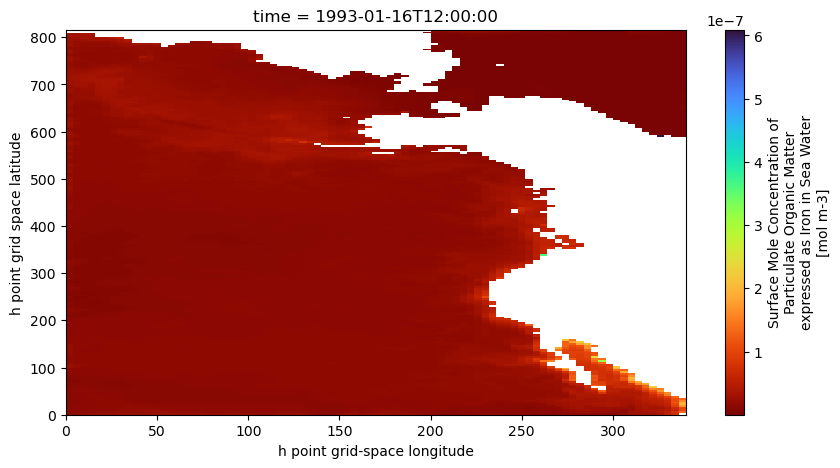

In [20]:
import matplotlib.pyplot as plt

da = ds["bfeos"].isel(time=0).coarsen(
    jh=4,
    ih=4,
    boundary="trim",
).mean()

plt.figure(figsize=(10, 5))

da.plot(
    x="ih",
    y="jh",
    cmap="turbo_r",
)

plt.show()

### Interactive rasterized plot with hvPlot

This cell plots a 2D slice of `talk` using hvPlot. The data are first selected with slice indexing and squeezed to avoid memory issues with virtual arrays.


In [15]:
import hvplot.xarray

da = (
    ds["phycos"]
    .isel(time=slice(0, 1), z_l=slice(0, 1))
    .squeeze(drop=True)
)

da.hvplot.quadmesh(
    rasterize=True,
    x="lon",
    y="lat",
    width=800,
    height=400,
    cmap = "turbo_r"
)

:DynamicMap   []
   :Image   [lon,lat]   (Total Alkalinity)

### Another memory-friendly plot example

This cell selects one time/depth slice of `no3`, coarsens the spatial grid, and plots the result. This is a safer pattern for quick-look plots from large virtual datasets.


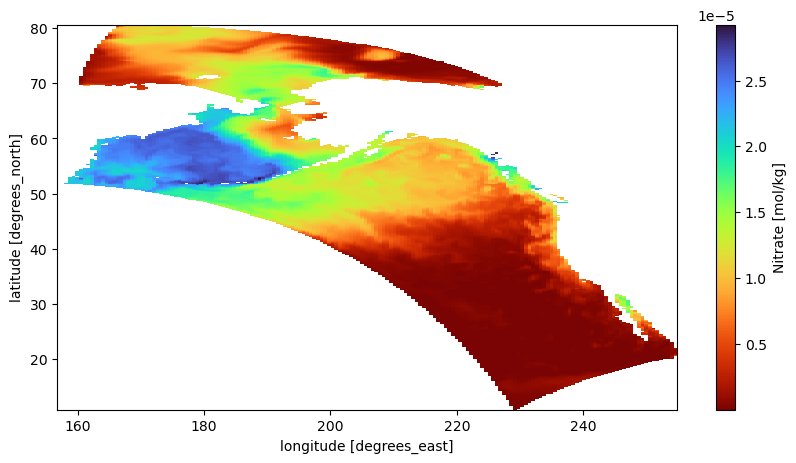

In [8]:
da = (
    ds["no3"]
    .isel(time=slice(0, 1), z_l=slice(0, 1))
    .squeeze(drop=True)
)

da_small = da.coarsen(
    lat=2,
    lon=2,
    boundary="trim",
).mean()

da_small.plot(
    x="lon",
    y="lat",
    figsize=(10, 5),
    cmap = "turbo_r"
)

## Troubleshooting

In [ ]:
# open one var
from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
var_url = f"s3://noaa-oar-cefi-regional-mom6-pds/northeast_pacific/full_domain/hindcast/monthly/{source_data_grid}/r20250912/volcello.nep.full.hcast.monthly.{source_data_grid}.r20250912.199301-202506.nc"
vds = open_virtual_dataset(
    url=var_url,
    parser=parser,
    registry=registry,
    loadable_variables=["time"],
    decode_times=True,
)
vds

In [19]:
# list the groups
import json
import icechunk
import zarr

icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "eeholmes/cefi/nepacific-icechunk"
icechunk_region = "us-west-2"

with open("source-cefi-creds.json") as f:
    source_creds = json.load(f)

storage = icechunk.s3_storage(
    bucket=icechunk_bucket,
    prefix=icechunk_prefix,
    region=icechunk_region,
    access_key_id=source_creds["aws_access_key_id"],
    secret_access_key=source_creds["aws_secret_access_key"],
    session_token=source_creds["aws_session_token"],
)

repo = icechunk.Repository.open(storage)
session = repo.readonly_session(branch="main")

root = zarr.open_group(session.store, mode="r")

def list_groups_only(group, path=""):
    for name, item in group.members():
        if isinstance(item, zarr.Group):
            child_path = f"{path}/{name}" if path else name
            print(child_path)
            list_groups_only(item, child_path)

list_groups_only(root)
    
print(root.tree())

daily
daily/raw
daily/raw/aux
daily/raw/main
daily/regrid
daily/regrid/aux
daily/regrid/main
monthly
monthly/raw
monthly/raw/aux1
monthly/raw/main
monthly/raw/ice_static
monthly/raw/aux2
monthly/raw/ocean_static
monthly/regrid
monthly/regrid/aux
monthly/regrid/aux2
monthly/regrid/main


/
├── daily
│   ├── raw
│   │   ├── aux
│   │   │   ├── btm_co3_ion (11869, 816, 342) float32
│   │   │   ├── btm_co3_sol_arag (11869, 816, 342) float32
│   │   │   ├── btm_co3_sol_calc (11869, 816, 342) float32
│   │   │   ├── btm_htotal (11869, 816, 342) float32
│   │   │   ├── btm_o2 (11869, 816, 342) float32
│   │   │   ├── ih (342,) float64
│   │   │   ├── jh (816,) float64
│   │   │   ├── mesozoo_200 (11869, 816, 342) float32
│   │   │   ├── no3os (11869, 816, 342) float32
│   │   │   ├── pco2surf (11869, 816, 342) float32
│   │   │   ├── phos (11869, 816, 342) float32
│   │   │   ├── ssh (11869, 816, 342) float32
│   │   │   ├── sshmax (11869, 816, 342) float32
│   │   │   ├── sshmin (11869, 816, 342) float32
│   │   │   ├── time (11869,) float64
│   │   │   ├── tob (11869, 816, 342) float32
│   │   │   └── tos (11869, 816, 342) float32
│   │   └── main
│   │       ├── chlos (11688, 816, 342) float32
│   │       ├── dissic (11688, 52, 816, 342) float32
│   │       ├── ih (342,) float64
│   │       ├── iq (343,) float64
│   │       ├── jh (816,) float64
│   │       ├── jq (817,) float64
│   │       ├── no3 (11688, 52, 816, 342) float32
│   │       ├── o2 (11688, 52, 816, 342) float32
│   │       ├── phycos (11688, 816, 342) float32
│   │       ├── po4 (11688, 52, 816, 342) float32
│   │       ├── si (11688, 52, 816, 342) float32
│   │       ├── so (11688, 52, 816, 342) float32
│   │       ├── talk (11688, 52, 816, 342) float32
│   │       ├── thetao (11688, 52, 816, 342) float32
│   │       ├── time (11688,) float64
│   │       ├── uo (11688, 52, 816, 343) float32
│   │       ├── vo (11688, 52, 817, 342) float32
│   │       ├── volcello (11688, 52, 816, 342) float32
│   │       ├── vollcello (11688, 52, 816, 342) float32
│   │       └── z_l (52,) float64
│   └── regrid
│       ├── aux
│       │   ├── btm_co3_ion (11869, 815, 341) float32
│       │   ├── btm_co3_sol_arag (11869, 815, 341) float32
│       │   ├── btm_co3_sol_calc (11869, 815, 341) float32
│       │   ├── btm_htotal (11869, 815, 341) float32
│       │   ├── btm_o2 (11869, 815, 341) float32
│       │   ├── lat (815,) float64
│       │   ├── lon (341,) float64
│       │   ├── mesozoo_200 (11869, 815, 341) float32
│       │   ├── no3os (11869, 815, 341) float32
│       │   ├── pco2surf (11869, 815, 341) float32
│       │   ├── phos (11869, 815, 341) float32
│       │   ├── ssh (11869, 815, 341) float32
│       │   ├── sshmax (11869, 815, 341) float32
│       │   ├── sshmin (11869, 815, 341) float32
│       │   ├── time (11869,) float64
│       │   ├── tob (11869, 815, 341) float32
│       │   └── tos (11869, 815, 341) float32
│       └── main
│           ├── chlos (11688, 815, 341) float32
│           ├── dissic (11688, 52, 815, 341) float32
│           ├── lat (815,) float64
│           ├── lon (341,) float64
│           ├── no3 (11688, 52, 815, 341) float32
│           ├── o2 (11688, 52, 815, 341) float32
│           ├── phycos (11688, 815, 341) float32
│           ├── po4 (11688, 52, 815, 341) float32
│           ├── si (11688, 52, 815, 341) float32
│           ├── so (11688, 52, 815, 341) float32
│           ├── talk (11688, 52, 815, 341) float32
│           ├── thetao (11688, 52, 815, 341) float32
│           ├── time (11688,) float64
│           ├── volcello (11688, 52, 815, 341) float32
│           ├── vollcello (11688, 52, 815, 341) float32
│           └── z_l (52,) float64
└── monthly
    ├── raw
    │   ├── aux1
    │   │   ├── ALB (396, 816, 342) float32
    │   │   ├── BHEAT (396, 816, 342) float32
    │   │   ├── BMELT (396, 816, 342) float32
    │   │   ├── BSNK (396, 816, 342) float32
    │   │   ├── CN (396, 5, 816, 342) float32
    │   │   ├── E2MELT (396, 816, 342) float32
    │   │   ├── EXT (396, 816, 342) float32
    │   │   ├── EXT_MAX (396, 816, 342) float32
    │   │   ├── EXT_MIN (396, 816, 342) float32
    │   │   ├── FA_X (396, 816, 343) float32
    │   │   ├── FA_Y (396, 817, 342) float32
    │   │   ├── FI_X (396, 816, 343) float32

In [ ]:
%%script false --no-raise
# remove above if you want to run this cell
# Delete everything in bucket

import json
import boto3

# Icechunk repo location on Source Cooperative
icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "eeholmes/cefi/nepacific-icechunk"  # delete everything under this prefix

# Load temporary Source upload credentials
with open("source-cefi-creds.json") as f:
    source_creds = json.load(f)

icechunk_region = "us-west-2"

s3 = boto3.client(
    "s3",
    region_name=icechunk_region,
    aws_access_key_id=source_creds["aws_access_key_id"],
    aws_secret_access_key=source_creds["aws_secret_access_key"],
    aws_session_token=source_creds["aws_session_token"],
)

def delete_s3_prefix(bucket, prefix):
    prefix = prefix.strip("/") + "/"

    paginator = s3.get_paginator("list_objects_v2")
    total = 0

    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        objects = [{"Key": obj["Key"]} for obj in page.get("Contents", [])]

        if objects:
            s3.delete_objects(
                Bucket=bucket,
                Delete={"Objects": objects},
            )
            total += len(objects)

    print(f"Deleted {total} objects from s3://{bucket}/{prefix}")

delete_s3_prefix(icechunk_bucket, icechunk_prefix)

In [9]:
%%script false --no-raise
# remove above if you want to run this cell

import json
import icechunk
import zarr

icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "eeholmes/cefi/nepacific-icechunk"
icechunk_region = "us-west-2"
#group_to_delete = ["monthly/raw/main", "monthly/raw/aux", "monthly/raw/aux2"]
group_to_delete = [ "monthly/regrid/aux", "monthly/regrid/aux1", "monthly/regrid/aux2", "monthly/regrid/main"]

with open("source-cefi-creds.json") as f:
    source_creds = json.load(f)

storage = icechunk.s3_storage(
    bucket=icechunk_bucket,
    prefix=icechunk_prefix,
    region=icechunk_region,
    access_key_id=source_creds["aws_access_key_id"],
    secret_access_key=source_creds["aws_secret_access_key"],
    session_token=source_creds["aws_session_token"],
)

repo = icechunk.Repository.open(storage)
session = repo.writable_session(branch="main")

root = zarr.open_group(session.store, mode="a")

for group_name in group_to_delete:
    if group_name in root:
        print(f"Deleting /{group_name}")
        del root[group_name]
    else:
        print(f"Not found: /{group_name}")

snapshot_id = session.commit("Remove temporary test groups")
print(snapshot_id)

Deleting /monthly/regrid/aux
Not found: /monthly/regrid/aux1
Deleting /monthly/regrid/aux2
Deleting /monthly/regrid/main
MRT9TNCHX9XRFM7MXYMG


### Full spec for authorizing virtual reads

In [2]:
import icechunk
import xarray as xr

# -------------------------------------------------------------------
# 1. Source data: original NOAA CEFI NetCDF files
# -------------------------------------------------------------------
source_data_bucket = "s3://noaa-oar-cefi-regional-mom6-pds"
source_data_prefix = "northeast_pacific/full_domain/hindcast/daily/regrid/r20250912"
source_data_region = "us-east-1"

source_data_url_prefix = source_data_bucket.rstrip("/") + "/"

# -------------------------------------------------------------------
# 2. Icechunk repo: public Source Cooperative location
# -------------------------------------------------------------------
icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "eeholmes/cefi/nepacific-icechunk"
icechunk_region = "us-west-2"

# -------------------------------------------------------------------
# 3. Authorize access to the original NOAA virtual chunks
# -------------------------------------------------------------------
# The Icechunk repo contains virtual references back to the public
# NOAA CEFI S3 bucket. Use anonymous access for these chunks.
credentials = icechunk.containers_credentials({
    source_data_url_prefix: icechunk.s3_credentials(anonymous=True)
})

# -------------------------------------------------------------------
# 4. Tell Icechunk which external virtual chunk locations are allowed
# -------------------------------------------------------------------
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=source_data_url_prefix,
        store=icechunk.s3_store(
            region=source_data_region,
            anonymous=True,
        ),
    ),
)

# -------------------------------------------------------------------
# 5. Point to the public Icechunk repo on Source Cooperative
# -------------------------------------------------------------------
storage = icechunk.s3_storage(
    bucket=icechunk_bucket,
    prefix=icechunk_prefix,
    region=icechunk_region,
    anonymous=True,
)

# -------------------------------------------------------------------
# 6. Open the Icechunk repo
# -------------------------------------------------------------------
repo = icechunk.Repository.open(
    storage,
    config=config,
    authorize_virtual_chunk_access=credentials,
)

session_read = repo.readonly_session(branch="main")

In [3]:
ds = xr.open_zarr(
    session_read.store,
    group="monthly/main",
    consolidated=False, 
    chunks={}
)
ds

/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 2TB
Dimensions:                      (time: 390, lat: 815, lon: 341, z_l: 52, zi: 76)
Coordinates:
  * time                         (time) datetime64[ns] 3kB 1993-01-16T12:00:0...
  * lat                          (lat) float64 7kB 10.81 10.89 ... 80.63 80.72
  * lon                          (lon) float64 3kB 156.9 157.2 ... 254.7 255.0
  * z_l                          (z_l) float64 416B 2.5 7.5 ... 6.25e+03
  * zi                           (zi) float64 608B 0.0 2.0 ... 6.25e+03 6.5e+03
Data variables: (12/356)
    FRAZIL                       (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    LSNK                         (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    MIB                          (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    bsios                        (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    btm_co3_ion                  (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    bfeos                        (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    ...                           ...
    wc_vert_int_nfix             (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    zmicroos                     (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    wc_vert_int_npp              (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    zmesoos                      (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    zoocos                       (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    wc_vert_int_juptake_nh4      (time, lat, lon) float32 434MB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
Attributes: (12/28)
    NumFilesInSet:          1
    title:                  NEP10k_202507_physics_bgc
    grid_type:              regular
    grid_tile:              N/A
    NCO:                    netCDF Operators version 5.2.4 (Homepage = http:/...
    cefi_rel_path:          cefi_portal/northeast_pacific/full_domain/hindcas...
    ...                     ...
    associated_files:       areacello: 19930101.ocean_static.nc
    external_variables:     areacello
    cefi_ori_category:      ocean_cobalt_omip_sfc
    cefi_filename:          zoocos.nep.full.hcast.monthly.regrid.r20250912.19...
    cefi_variable:          zoocos
    cefi_ori_filename:      ocean_cobalt_omip_sfc.199301-202506.zoocos.nc

## Notes

Notes on groups in monthly:

- *monthly/main* 350+ variables have 390 unique  and monotonically increasing months.
- *monthly/aux* 92 variables have 396 months of which 390 are unique and 6 are duplicated.
- *monthly/aux2* 1 variable has 396 months of which 390 are unique but not same times as aux group.

**Chunking and performance note** This Icechunk repository is a virtual access layer: the original CEFI NetCDF files remain unchanged in the NOAA S3 bucket, and Icechunk stores references back to those source chunks. The chunks in the netcdfs are quite large (>100Mb) when the data are 4D (with depth).

**Path to a truly ARCO/ML-ready dataset** A fully analysis-ready, cloud-optimized version of this archive would require materializing a new derived dataset rather than relying only on virtual references to the original NetCDF chunks. In that workflow, all variables would be opened from the source files, aligned to a common daily time axis, checked for coordinate problems, and written into a new Zarr or Icechunk store with a single consistent chunking scheme chosen for analysis and machine-learning access patterns. This would allow all variables, including both yearly-file and full-period variables, to live in one dataset with predictable dimensions, shared coordinates, explicit missing values where coverage differs, and chunks that do not have to preserve source-file boundaries. The tradeoff is that this product would copy and rewrite the data, requiring more storage and compute, but it would provide a true ARCO dataset optimized for repeated downstream analysis rather than a lightweight virtual access layer.

**Alternative source chunking** If the source files had used time=1 chunks, the virtual slicing problem would largely disappear because calendar periods could be assembled without splitting source chunks. Users could then rechunk the opened dataset with xarray or Dask, for example ds.chunk({"time": 100}), to create larger logical chunks for analysis or ML workflows. However, this would only change the Dask-level chunking after the dataset is opened; each 100-step logical chunk would still be assembled from 100 one-day source chunks. Thus time=1 source chunking improves virtual slicing flexibility, but it can increase request counts and read overhead for workflows that need many consecutive time steps.